# Download Daymet

Daymet provides gridded meteorological data for North American at 1km spatial resolution with daily timestep from 1980 ~ present. [website](https://daac.ornl.gov/cgi-bin/dsviewer.pl?ds_id=1328) and [user guide](https://daac.ornl.gov/DAYMET/guides/Daymet_V3_CFMosaics.html)

Available variables:

| Variable | Description (units) |
| ---- | ---- |
| tmax | Daily maximum 2-meter air temperature (°C) |
| tmin | Daily minimum 2-meter air temperature (°C) |
| prcp | Daily total precipitation (mm/day) |
| srad | Incident shortwave radiation flux density (W/m2) |
| vp   | Water vapor pressure (Pa) |
| swe  | Snow water equivalent (kg/m2) |
| dayl | Duration of the daylight period (seconds/day) |

Notes:
 - The Daymet calendar is based on a standard calendar year. All Daymet years, including leap years, have 1 - 365 days. For leap years, the Daymet database includes leap day (February 29) and values for December 31 are discarded from leap years to maintain a 365-day year.

In [ ]:
import pygeoutils as geoutils

: 

In [ ]:
# Use branch v1.3

import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 150

: 

In [ ]:
# import watershed_workflow
# import watershed_workflow.ui
import logging
# watershed_workflow.ui.setup_logging(1,None)

import numpy as np
import rasterio
import fiona
# import watershed_workflow.daymet

import os,sys
import numpy as np
import pandas
from matplotlib import pyplot as plt
from matplotlib import cm as pcm
import logging
import pandas as pd
# import seaborn as sns
import shapely
import copy
import scipy
import datetime
import netCDF4 as nc

# import watershed_workflow 
# import watershed_workflow.source_list
# import watershed_workflow.ui
# import watershed_workflow.utils
# import watershed_workflow.plot
# import watershed_workflow.mesh
# import watershed_workflow.condition
# import watershed_workflow.densify_rivers_hucs
# import watershed_workflow.create_river_mesh
# watershed_workflow.ui.setup_logging(1,None)

import pygeoutils as geoutils
from pynhd import NLDI
# import ipympl


: 

In [3]:
sources = watershed_workflow.source_list.get_default_sources()
name = 'Village_gauge_T' # name the domain, used in filenames, etc
hucs = ['12020006'] # a list of HUCs to run
huc_level = None # if provided, an int setting the level at which to include HUC boundaries
crs = watershed_workflow.crs.daymet_crs()

In [4]:
# Get shapefile for the domain of analysis. Use the USGS gauge ID to pull data
sources = watershed_workflow.source_list.get_default_sources()
my_hucs = []
for huc in hucs:
    _, ws = watershed_workflow.get_hucs(sources['HUC'], huc, huc_level, crs)
    my_hucs.extend(ws)

# Option 1: Get the basin gauge boundary directly from the shp
gauge_ID='08041500' # National Water Service streamflow gauge ID (USGS ID)
watershed_gauge = NLDI().get_basins([gauge_ID])
watershed_gauge.to_file(f'../data-processed/basin/watershed_gaugeID_{gauge_ID}.shp')
# path_shp_basin = 'data/basin/watershed_gauge' # Path to save shp
_, watershed_gauge=watershed_workflow.get_shapes(f'../data-processed/basin/watershed_gaugeID_{gauge_ID}.shp',in_crs = watershed_gauge.crs,out_crs = watershed_workflow.crs.daymet_crs())
watershed_area = watershed_gauge[0].area/1e6 # Area in [km2]
# my_hucs = watershed_gauge[0]
my_hucs = [my_hucs[0].intersection(watershed_gauge[0])]
print('Drainage area = ', watershed_area, 'km^2')

# Get watershed in the right format
watershed = watershed_workflow.split_hucs.SplitHUCs(my_hucs)

2023-03-07 14:29:41,757 - root - INFO: 
2023-03-07 14:29:41,761 - root - INFO: Loading level 8 HUCs in 12020006
2023-03-07 14:29:41,764 - root - INFO: ------------------------------
2023-03-07 14:29:41,769 - root - INFO: Using HUC file "/Users/gpq/ORNL/Projects/SETx_Urban/Jupyter_Notebooks/watershed_workflow/Village_creek_tin/scripts/data/hydrography/NHDPlus_H_1202_GDB/NHDPlus_H_1202.gdb"
2023-03-07 14:29:41,839 - root - INFO: ... found 1 HUCs
2023-03-07 14:29:41,840 - root - INFO:   -- 12020006
2023-03-07 14:29:41,841 - root - INFO: Converting to out_crs
2023-03-07 14:29:41,852 - root - INFO: Converting to shapely
2023-03-07 14:29:41,909 - root - INFO: 
2023-03-07 14:29:41,909 - root - INFO: Loading shapes
2023-03-07 14:29:41,909 - root - INFO: ------------------------------
2023-03-07 14:29:41,909 - root - INFO: Loading file: 'data/basin/watershed_gaugeID_08041500.shp'
2023-03-07 14:29:41,913 - root - INFO: ... found 1 shapes
2023-03-07 14:29:41,914 - root - INFO: Converting to shape

Drainage area =  2125.4720598255394 km^2


## import watershed

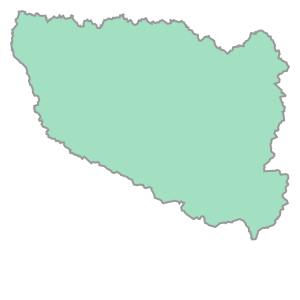

In [5]:
# crs, watershed = watershed_workflow.get_split_form_shapes(watershed_shapefile)
# logging.info(f'crs: {crs}')

bounds = watershed.exterior()
bounds


## Download Daymet

returned raw data has `dim(nband, ncol, nrow)`

Note that here we need two files -- the actual data and the typical year data.

The first cell downloads the raw data and generates the actual data file used by ATS, the second cell averages days, smooths the data, and writes a typical year.

In [6]:
help(watershed_workflow.daymet.daymetToATS)

Help on function daymetToATS in module watershed_workflow.daymet:

daymetToATS(dat, smooth=False, smooth_filter=False, nyears=None)
    Accepts a numpy named array of DayMet data and returns a dictionary ATS data. 
    It has the option to smooth the data.
    Parameters:
        dat, dict
            daymet dictinary
        smooth, bool
            whether to smooth the data or not
        smooth_filter, bool
            whether to apply a savgol filter for smoothing. Default is False.
        nyears, int
            how many years to repeat the typical year. Default is to get the same length as the raw data.



In [8]:
# Note: if the data is not being downloded then probably the id had changed and the line [60] on manager_daymet.py must be updated. 
# line [60] --> URL = "https://thredds.daac.ornl.gov/thredds/ncss/ornldaac/2129/daymet_v4_daily_na_{variable}_{year}.nc"

bounds = watershed.exterior().bounds

# a dictionary of outputs -- will include all filenames generated
2016-2018
start = "1-2016"
end = "365-2018"
outputs = {}
outputs['daymet_filename'] = f'../../../global_data/rainfall_input_ATS/{name}_DayMet_2016_2018.h5'

dat, x, y = watershed_workflow.daymet.collectDaymet(bounds, crs, start, end)

# Save data into HD5 format
ats = watershed_workflow.daymet.daymetToATS(dat)
attrs = watershed_workflow.daymet.getAttrs(bounds, start, end)
watershed_workflow.daymet.writeHDF5(ats, x, y, attrs, outputs['daymet_filename'])

2023-03-07 14:31:46,694 - root - INFO: downloading variables: ['tmin', 'tmax', 'prcp', 'srad', 'vp', 'swe', 'dayl']
2023-03-07 14:31:46,703 - root - INFO: Collecting DayMet file to tile bounds: [-94.85940000000001, 30.3616, -94.1274, 30.900000000000002]
2023-03-07 14:31:46,703 - root - INFO:   Using existing: /Users/gpq/ORNL/Projects/SETx_Urban/Jupyter_Notebooks/watershed_workflow/Village_creek_tin/scripts/data/meteorology/daymet/daymet_tmin_2016_30.9000x-94.8594_30.3616x-94.1274.nc
2023-03-07 14:31:46,734 - root - INFO: Collecting DayMet file to tile bounds: [-94.85940000000001, 30.3616, -94.1274, 30.900000000000002]
2023-03-07 14:31:46,735 - root - INFO:   Using existing: /Users/gpq/ORNL/Projects/SETx_Urban/Jupyter_Notebooks/watershed_workflow/Village_creek_tin/scripts/data/meteorology/daymet/daymet_tmax_2016_30.9000x-94.8594_30.3616x-94.1274.nc
2023-03-07 14:31:46,764 - root - INFO: Collecting DayMet file to tile bounds: [-94.85940000000001, 30.3616, -94.1274, 30.900000000000002]
20

In [ ]:

# a dictionary of outputs -- will include all filenames generated
2010-2020
start = "1-2010"
end = "365-2020"
outputs = {}
outputs['daymet_filename'] = f'../../../global_data/rainfall_input_ATS/{name}_DayMet_2010_2020.h5'

dat, x, y = watershed_workflow.daymet.collectDaymet(bounds, crs, start, end)

# Save data into HD5 format
ats = watershed_workflow.daymet.daymetToATS(dat)
attrs = watershed_workflow.daymet.getAttrs(bounds, start, end)
watershed_workflow.daymet.writeHDF5(ats, x, y, attrs, outputs['daymet_filename'])

# 1980-2020
start = "1-1980"
end = "365-2020"
outputs = {}
outputs['daymet_filename'] = f'../../../global_data/rainfall_input_ATS/{name}_DayMet_1980_2020.h5'

dat, x, y = watershed_workflow.daymet.collectDaymet(bounds, crs, start, end)

# Save data into HD5 format
ats = watershed_workflow.daymet.daymetToATS(dat)
attrs = watershed_workflow.daymet.getAttrs(bounds, start, end)
watershed_workflow.daymet.writeHDF5(ats, x, y, attrs, outputs['daymet_filename'])



# White to ATS format

In [8]:
# Daymet data for spinup

outputs['daymet_spinup_filename'] = f'../../../global_data/rainfall_input_ATS/{name}/{name}_DayMet_typical_1980_2020.h5'
ats_typ = watershed_workflow.daymet.daymetToATS(dat, smooth=True, smooth_filter=True, nyears=40)
watershed_workflow.daymet.writeHDF5(ats_typ, x, y, attrs, outputs['daymet_spinup_filename'])

2023-03-06 08:19:23,942 - root - INFO: input dat shape: (14965, 64, 73)
2023-03-06 08:19:23,945 - root - INFO: Converting to ATS met input
2023-03-06 08:19:25,588 - root - INFO: averaging daymet by taking the average for each day across the actual years.
2023-03-06 08:19:25,638 - root - INFO: smoothing tmin using savgol filter, window = 61 d, poly order = 2
2023-03-06 08:19:25,859 - root - INFO: smoothing tmax using savgol filter, window = 61 d, poly order = 2
2023-03-06 08:19:26,058 - root - INFO: smoothing prcp using savgol filter, window = 61 d, poly order = 2
2023-03-06 08:19:26,570 - root - INFO: smoothing srad using savgol filter, window = 61 d, poly order = 2
2023-03-06 08:19:26,769 - root - INFO: smoothing vp using savgol filter, window = 61 d, poly order = 2
2023-03-06 08:19:27,066 - root - INFO: smoothing swe using savgol filter, window = 61 d, poly order = 2
2023-03-06 08:19:27,380 - root - INFO: smoothing dayl using savgol filter, window = 61 d, poly order = 2
2023-03-06 08

In [9]:
# calculate the basin-averaged, annual-averaged precip rate
precip_total = ats_typ['precipitation rain [m s^-1]'] + ats_typ['precipitation snow [m SWE s^-1]']
mean_precip = precip_total.mean()
logging.info(f'Mean annual precip rate [m s^-1] = {mean_precip}')

2023-03-06 08:19:48,541 - root - INFO: Mean annual precip rate [m s^-1] = 4.727455895304543e-08
